# Chameleon project prototype

Implementing neorv32, collecting data from mpu9250 accelerometer sensors, generating a dynamic key based on their values and supplying the key to neorv32, which uses it for instruction set randomisation.  


# About hardware design

neorv32 bootloader UART (19200) pins:  
* PMOD1_0 (RX)  
* PMOD1_1 (TX)  

Uartlite pins for communication between this notebook and Esp32 with sensors:  
* PMOD1_4 (RX) - going to green (TX) of Esp32 board  
* PMOD1_5 (TX) - going to blue (RX) of Esp32 board  

Engine driving pin (output):  
* PMOD1_6  

Trap (invalid instruction) detecting pin (output):  
* PMOD1_7  

~~SDA and SCL pins that could probably be removed (attempting to use I2C for reading sensors failed):  ~~
~~* PMOD1_2~~  
~~* PMOD1_3~~  

Unused:
* PMOD1_2  
* PMOD1_3  


# Note about displaying current keys
The main key can be sent from the PS to the display Esp32 through the same UART that used to get sensor readings. 
To send the secondary key (cyclicly generated based on the IMEM) it would have to be propagated as top level signal of the processor, read by the PS (BRAM controller maybe), and sent through the same UART.

In [1]:
overlay_fname = "neorv32_isr.bit"

#import ipdb # alternative to pdb that works in jupyter notebook (pip3 install ipdb)
from IPython.core.debugger import set_trace
import os, subprocess, sys, re, time, inspect, logging, random, json, math, glob, datetime
from pathlib import Path
from pynq import Overlay, allocate, MMIO
from pynq.lib import AxiGPIO
from uartlite import UartAXI
import threading
import queue
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from sklearn.neighbors import KernelDensity
import struct
import hashlib

logger = logging.getLogger()
logger.setLevel(logging.DEBUG) # logging.INFO)

BASE_DIR = Path('/home/xilinx/neorv32_isr')
ol = Overlay(str(BASE_DIR / overlay_fname))
uart = UartAXI(ol.ip_dict['axi_uartlite_0']['phys_addr'])
uart.setupCtrlReg()

    
def send_main_key_to_display(main_key):
    uart.write(f'key_1:{main_key[:20]}...\n')
    
def send_secondary_key_to_display():
    val = str(ol.axi_bram_ctrl_0.mmio.read(0))
    second_key = hashlib.sha256(val.encode('utf-8')).hexdigest()[:20]
    print(f'Sending 2nd key: {second_key}...')
    uart.write(f'key_2:0x{second_key}...\n')

def trap_detected():
    axi_gpio = AxiGPIO(ol.ip_dict['axi_gpio_trap_detect'])
    return axi_gpio.channel1.read()

def reset_trap():
    axi_gpio = AxiGPIO(ol.ip_dict['axi_gpio_trap_detect'])
    mask = 1
    axi_gpio.channel2.write(1, mask)
    axi_gpio.channel2.write(0, mask)

def set_neorv32_key(key_val_128_bit):
    axi_gpio = AxiGPIO(ol.ip_dict['key_transfer/axi_gpio_0'])
    axi_gpio_data_channel = axi_gpio.channel1
    axi_gpio_control_channel = axi_gpio.channel2
    shift_en = axi_gpio_control_channel[0]
    latch = axi_gpio_control_channel[1]
    latch.write(0)
    if type(key_val_128_bit) == str:
        key_val_128_bit = int(key_val_128_bit.split('0x')[-1], 16)
    mask_32_bit = (1 << 32) - 1
    for i in reversed(range(4)):
        key_part = key_val_128_bit >> (i * 32) & mask_32_bit
        axi_gpio_data_channel.write(key_part, mask_32_bit)
        shift_en.write(1)
        shift_en.write(0)
    latch.write(1)
    latch.write(0)
    
    send_main_key_to_display(hex(key_val_128_bit))
        
def uart_read():
    last_recv = time.time()
    one_collected = False
    while time.time() - last_recv < 0.0001 or not one_collected:
        if not uart.currentStatus()['RX_VALID']:
            continue
        one_collected = True
        
        while uart.currentStatus()['RX_VALID']:
            yield uart.read(1)
        last_recv = time.time()
        
def parse_multiple_mpu9250_data(s):
    mpu9250_dict = {}
    individual_datas = s.split()
    for i, data in enumerate(s.split()):
        vals = [float(val) for val in data.split(':')[1].split(',')]
        mpu9250_dict[i] = {
                'accel_x' : vals[0],
                'accel_y' : vals[1],
                'accel_z' : vals[2],
                'gyro_x'  : vals[3],
                'gyro_y'  : vals[4],
                'gyro_z'  : vals[5]
                # ignore temperature because it can change during demo
                # generating an incorrect key 
                # 'temp'    : vals[6]
            }
    return mpu9250_dict

def mpu9250_dict_to_features_dict(mpu9250_dict):
    features_dict = {}
    for sensor_i, sensor_dict in mpu9250_dict.items():
        # skip first sensor because differences 
        # are calculated always from it
        if sensor_i == 0:
            continue
        for feature_name in sensor_dict.keys():
            features_dict[f'{feature_name}_0_{sensor_i}'] = mpu9250_dict[0][feature_name] - sensor_dict[feature_name]
    return features_dict

        
def read_mpu9250(average_over=1, verbose=False):
    """average_over reads each sensor multiple times and makes average of readings."""
    uart.write(f'read_{average_over}\n')
    response = ''
    while True:
        response += ''.join(uart_read())
        if response.endswith('\n'):
            if verbose:
                print(f'Response from UART:\n{response}')
            return parse_multiple_mpu9250_data(response[:-1])
        uart.write('more\n')

# functions convenient for averaging readings for consistency
def read_mpu9250_n_times(n, average_over): 
    return [read_mpu9250(average_over) for _ in range(n)]
def many_mpu9250_dicts_to_features_dicts(list_of_mpu9250_dicts):
    return [mpu9250_dict_to_features_dict(d) for d in list_of_mpu9250_dicts]

# def kde_density_score(X, X_new, bandwidth=None):
#     """
#     KDE-based typicality score in [0,1], normalized by the max density on the training set.

#     Parameters
#     ----------
#     X : array-like, shape (n_samples,) or (n_samples, d)
#         Training samples.
#     X_new : array-like, shape (m,) or (m, d)
#         Query points to score.
#     bandwidth : float or None
#         Bandwidth. If None:
#           - SciPy: uses 'scott' rule (default).
#           - scikit-learn: uses a simple rule-of-thumb.
#     backend : {"auto","scipy","sklearn"}
#         Which KDE implementation to use. "auto" tries SciPy, then scikit-learn.

#     Returns
#     -------
#     score : ndarray, shape (m,)
#         Normalized scores in [0,1].
#     log_density : ndarray, shape (m,)
#         Log density values (un-normalized, up to a constant).
#     """
#     X = np.asarray(X, dtype=float)
#     X_new = np.asarray(X_new, dtype=float)

#     if X.ndim == 1:
#         X = X[:, None]
#     if X_new.ndim == 1:
#         X_new = X_new[:, None]


#     # Simple isotropic bandwidth heuristic if not provided
#     if bandwidth is None:
#         n, d = X.shape
#         # Scott factor n^(-1/(d+4)), with 1.06 * mean std (Silverman-ish for 1D)
#         factor = n ** (-1.0 / (X.shape[1] + 4.0))
#         bw = 1.06 * np.mean(X.std(axis=0, ddof=1)) * factor
#         bandwidth_val = max(bw, 1e-12)
#     else:
#         bandwidth_val = float(bandwidth)

#     kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth_val)
#     kde.fit(X)

#     log_density = kde.score_samples(X_new)
#     log_density_train = kde.score_samples(X)

#     # Normalize to [0,1] via log-space: score = exp(log_f - max_log_f_train)
#     max_log = np.max(log_density_train)
#     score = np.exp(log_density - max_log)
#     # Numerical safety
#     score = np.clip(score, 0.0, 1.0)

#     return score, log_density

# def generate_key_from_mpu_training_df(training_features_df, bit_width=128):
#     key = 0
#     for col_name in training_features_df:
#         mean_float = training_features_df[col_name].mean()
#         # reinterpret (not cast) float/double bits as if it was an integer
#         mean_bits = struct.unpack('Q', struct.pack('d', mean_float))[0]
#         key = (key << 5) + key + mean_bits
#     key = key & ((1 << bit_width) - 1)
#     return key


def hash_key(key, bit_width=128):
    if bit_width not in [128, 256, 512]:
        raise ValueError('bit_width must be one of [128, 256, 512]')
    if bit_width == 128:
        # TODO: consider truncating sha instead:
        # https://csrc.nist.gov/csrc/media/events/first-cryptographic-hash-workshop/documents/kelsey_truncation.pdf
        hasher = hashlib.md5()
    elif bit_width == 256:
        hasher = hashlib.sha256()
    elif bit_width == 512:
        hasher = hashlib.sha512()
    hasher.update(key.encode('utf-8'))
    return hasher.hexdigest()

def get_ranges_and_offsets_from_features_df(df, verbose=False):
    """
    For each feature column, compute the range_size and offset.
    Offset is defined as the difference between the min value and the closest lower multiple of the range.
    """
    range_sizes = []
    offsets = []
    for col in df.columns:
        min_val = df[col].min()
        max_val = df[col].max()
        # widen the range a bit to avoid floating point issues
        widening_val = abs(max_val - min_val) * 0.01
        min_val -= widening_val
        max_val += widening_val

        range_size = max_val - min_val
        # Find the closest lower multiple of range_size
        if range_size == 0:
            offset = 0
        else:
            closest_lower_multiple = (min_val // range_size) * range_size
            offset = min_val - closest_lower_multiple
        range_sizes.append(range_size)
        offsets.append(offset)
        if verbose:
            print(f'Feature: {col}, Min: {min_val}, Max: {max_val}, Range size: {range_size}, Offset: {offset} Closest lower multiple: {closest_lower_multiple}')
    print()
    return range_sizes, offsets


def generate_key_from_features_row(row, range_sizes, offsets, verbose=False):
    key_parts = []
    if type(row) is not pd.Series:
        row = pd.Series(row)
    for i, col in enumerate(row.index):
        value = row[col]
        range_size = range_sizes[i]
        offset = offsets[i]
        if range_size == 0:
            index = 0
        else:
            index = int((value - offset) // range_size)
        key_parts.append(str(index))
        if verbose:
            print(f'Feature: {col}, Value: {value}, Range size: {range_size}, Offset: {offset}, Index: {index}')
    key = '_'.join(key_parts)
    return key

def generate_key_from_features_df(df, range_sizes, offsets, verbose=False):
    # using any row should be fine, but if we use kde score to restrict valid values, then mean should be used
    return generate_key_from_features_row(df.mean(axis=0), range_sizes, offsets, verbose=verbose)

def store_ranges_and_offsets(range_sizes, offsets, filename='isr_feature_ranges_offsets.csv'):
    df = pd.DataFrame({'range_size': range_sizes, 'offset': offsets})
    df.to_csv(filename, index=False)

def load_ranges_and_offsets(filename='isr_feature_ranges_offsets.csv'):
    df = pd.read_csv(filename)
    return df['range_size'].tolist(), df['offset'].tolist()

def visualize_key_generation(df, range_sizes, offsets, key, rows_limit=None):
    # make sure x=0 is always in the middle of a plot
    # plot indices of each potential range boundaries
    # make the chosen index with a different color to indicate it
    num_features = len(df.columns)
    num_rows = (num_features + 2) // 3
    if rows_limit is not None:
        num_rows = min(num_rows, rows_limit)
    num_cols = min(3, num_features)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 4*num_rows))
    fig.suptitle(f'Key (unhashed): {key}', fontsize=16)
    if num_features == 1:
        axes = np.array([axes])
    for i, col in enumerate(df.columns):
        if rows_limit is not None:
            if rows_limit == 1:
                ax = axes[i % num_cols]
            if i // rows_limit >= num_cols:
                break
        else:
            ax = axes[i // num_cols, i % num_cols]
        values = df[col]
        range_size = range_sizes[i]
        offset = offsets[i]
        if range_size == 0:
            ax.text(0.5, 0.5, 'No variation in data', horizontalalignment='center', verticalalignment='center')
            ax.set_title(f'Feature: {col}')
            continue
        min_val = values.min()
        max_val = values.max()
        # # widen the range a bit to avoid floating point issues
        # widening_val = abs(max_val - min_val) * 0.01
        # min_val -= widening_val
        # max_val += widening_val
        greates_val = max(abs(min_val), abs(max_val)) * 1.5
        visible_min = - abs(greates_val) 
        visible_max = abs(greates_val)
        ax.set_xlim(visible_min, visible_max)
        values.plot.kde(ax=ax, color='blue', alpha=0.7, bw_method=0.03)
        mean_value = values.mean()
        chosen_index = int((mean_value - offset) // range_size)
        chosen_boundary_start = offset + chosen_index * range_size
        rect = plt.Rectangle((chosen_boundary_start, 0), range_size, ax.get_ylim()[1], color='orange', alpha=0.3)
        ax.add_patch(rect)
        ax.axvline(mean_value, color='red', linestyle='--')

        boundaries = []
        boundary_0_start = offset 
        boundary_abs_end = (abs(greates_val) - offset) // range_size * range_size + offset
        b = boundary_0_start
        boundaries.append(b)
        b_backwards = b - range_size
        boundaries.insert(0, b_backwards)
        while b <= boundary_abs_end:
            b += range_size
            b_backwards -= range_size
            boundaries.insert(0, b_backwards)
            boundaries.append(b)
        boundaries = [b for b in boundaries if visible_min <= b <= visible_max]

        first_boundary_after_0_index = None
        for i, b in enumerate(boundaries):
            if b > 0 and first_boundary_after_0_index is None:
                first_boundary_after_0_index = i

        for i, b in enumerate(boundaries):
            ax.axvline(b, color='black', linestyle='-', alpha=0.5)
            boundary_index = i - first_boundary_after_0_index 
            color = 'black' if boundary_index != chosen_index else 'red'
            middle_x = b + range_size / 2
            # bold if chosen index
            # small font size, unless chosen
            kwargs = {'rotation':0, 'verticalalignment':'top', 'color':color, 'alpha':0.7, 'fontsize':7}
            if boundary_index == chosen_index:
                kwargs['fontsize'] = 14
                kwargs['fontweight'] = 'bold'
                # stroke black
                kwargs['path_effects'] = [path_effects.withStroke(linewidth=2, foreground='black')]
            ax.text(middle_x, ax.get_ylim()[1]*0.9, str(boundary_index), **kwargs)
        # Highlight chosen boundary area by drawing rect over it alpha 0.3

        ax.set_title(f'{col}')
        ax.set_ylabel('Frequency')


    # plt.subplots_adjust(left=0.075, right=0.955, bottom=0.06, top=0.916, wspace=0.218, hspace=0.98)
    plt.show()


# def visualize_key_generation(df, range_sizes, offsets, key, rows_limit=None):
#     # make sure x=0 is always in the middle of a plot
#     # plot indices of each potential range boundaries
#     # make the chosen index with a different color to indicate it
#     num_features = len(df.columns)
#     num_rows = (num_features + 2) // 3
#     if rows_limit is not None:
#         num_rows = min(num_rows, rows_limit)
#     num_cols = min(3, num_features)
#     fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 4*num_rows))
#     fig.suptitle(f'Key (unhashed): {key}', fontsize=16)
#     if num_features == 1:
#         axes = np.array([axes])
#     for i, col in enumerate(df.columns):
#         if rows_limit is not None:
#             if rows_limit == 1:
#                 ax = axes[i % num_cols]
#             if i // rows_limit >= num_cols:
#                 break
#         else:
#             ax = axes[i // num_cols, i % num_cols]
#         values = df[col]
#         range_size = range_sizes[i]
#         offset = offsets[i]
#         if range_size == 0:
#             ax.text(0.5, 0.5, 'No variation in data', horizontalalignment='center', verticalalignment='center')
#             ax.set_title(f'Feature: {col}')
#             continue
#         min_val = values.min()
#         max_val = values.max()
#         # # widen the range a bit to avoid floating point issues
#         # widening_val = abs(max_val - min_val) * 0.01
#         # min_val -= widening_val
#         # max_val += widening_val
#         greates_val = max(abs(min_val), abs(max_val)) * 1.5
#         visible_min = - abs(greates_val) 
#         visible_max = abs(greates_val)
#         ax.set_xlim(visible_min, visible_max)

#         # Plot all values
#         ax.hist(values, bins=50, color='blue', alpha=0.7)

#         mean_value = values.mean()
#         chosen_index = int((mean_value - offset) // range_size)
#         chosen_boundary_start = offset + chosen_index * range_size
#         rect = plt.Rectangle((chosen_boundary_start, 0), range_size, ax.get_ylim()[1], color='orange', alpha=0.3)
#         ax.add_patch(rect)
#         ax.axvline(mean_value, color='red', linestyle='--')

#         boundaries = []
#         boundary_0_start = offset 
#         boundary_abs_end = (abs(greates_val) - offset) // range_size * range_size + offset
#         b = boundary_0_start
#         boundaries.append(b)
#         b_backwards = b - range_size
#         boundaries.append(b_backwards)
#         while b <= boundary_abs_end:
#             b += range_size
#             b_backwards -= range_size
#             boundaries.append(b_backwards)
#             boundaries.append(b)
#         boundaries = [b for b in boundaries if visible_min <= b <= visible_max]

#         for b in boundaries:
#             ax.axvline(b, color='black', linestyle='-', alpha=0.5)
#             boundary_index = int((b - offset) / range_size)
#             color = 'black' if boundary_index != chosen_index else 'blue'
#             middle_x = b + range_size / 2
#             # bold if chosen index
#             # small font size, unless chosen
#             kwargs = {'rotation':0, 'verticalalignment':'top', 'color':color, 'alpha':0.7, 'fontsize':7}
#             if boundary_index == chosen_index:
#                 kwargs['fontsize'] = 10
#                 kwargs['fontweight'] = 'bold'
#             ax.text(middle_x, ax.get_ylim()[1]*0.9, str(boundary_index), **kwargs)
#         # Highlight chosen boundary area by drawing rect over it alpha 0.3

#         ax.set_title(f'{col}')
#         ax.set_ylabel('Frequency')


#     # plt.subplots_adjust(left=0.075, right=0.955, bottom=0.06, top=0.916, wspace=0.218, hspace=0.98)
#     plt.show()

def average_dict_values(dict_list):
    if not dict_list:
        return {}
    keys = dict_list[0].keys()
    avg_dict = {}
    for key in keys:
        avg_dict[key] = sum(d[key] for d in dict_list) / len(dict_list)
    return avg_dict

def compute_key_from_mpu_data(range_sizes, offsets, average_over, n=1, verbose=False):
    mpu9250_dicts = read_mpu9250_n_times(n, average_over)
    features_dicts = many_mpu9250_dicts_to_features_dicts(mpu9250_dicts)
    feature_dict = average_dict_values(features_dicts)
    key = generate_key_from_features_row(feature_dict.values(), range_sizes, offsets)
    if verbose:
        print('key:', key)
    hashed_key = hash_key(key, bit_width=128)
    # send key for neorv32
    if verbose:
        print('hashed key:', hashed_key)
    return hashed_key, key

def reset_cpu(delay=0.001):
    ''' AXI GPIO controlled reset, active-low. '''
    #gpio_en_cpu_reset_server_request_put_out.write(0)
    ol.axi_gpio_cpu_reset.channel1.write(0, 1)
    time.sleep(delay)
    ol.axi_gpio_cpu_reset.channel1.write(1, 1)
    time.sleep(delay)



# Load previous training results, and generate a key from a new reading
Results mean: range sizes and offsets for each feature. Indicating key part granularity (range sizes) and alignment (offsets).

Don't run training if loading previous results (unless overwriting previous results is intended).

In [2]:
range_sizes, offsets = load_ranges_and_offsets()
print('Loaded')
hashed_key, key = compute_key_from_mpu_data(range_sizes, offsets, average_over=50, n=1)
print('key:', hashed_key, f'(unhashed:{key}')
set_neorv32_key(hashed_key)

# for i in range(15):
#     compute_and_set_key(range_sizes, offsets)

Loaded
key: 9e69215ee222aed0cc1774ab4523d5c0 (unhashed:-1_-4_7_-3_-2_-3_6_1_-8_-2_8_-5_0_0_7_8_15_-5


# Start CPU
This will run the bootloader and allow to send encrypted. The main key must be set before that by either:  
* loading the previous key (cell above)  
* running and finishing training cells (below)  

In [4]:
reset_cpu()

# Test connectivity

In [2]:
mpu9250_dict = read_mpu9250(average_over=3)
print(mpu9250_dict)

{0: {'accel_x': 0.13, 'accel_y': -0.22, 'accel_z': 11.3, 'gyro_x': -0.63, 'gyro_y': 5.41, 'gyro_z': -1.21}, 1: {'accel_x': 0.14, 'accel_y': 0.06, 'accel_z': 10.19, 'gyro_x': 0.75, 'gyro_y': 6.37, 'gyro_z': -0.37}, 2: {'accel_x': -0.46, 'accel_y': -0.43, 'accel_z': 12.34, 'gyro_x': 0.85, 'gyro_y': 0.1, 'gyro_z': 0.9}, 3: {'accel_x': 0.04, 'accel_y': -0.35, 'accel_z': 10.13, 'gyro_x': -5.11, 'gyro_y': -1.28, 'gyro_z': 0.78}}


# Training/Calibration
Collecting data which records characteristic of our hardware/sensors. Collected data will be used for key generation. Afterwards, when the system is deployed, if a reading from MPU9250 sensor is similar enough to previously collected data, then a correct key will be generated.

Due to lack of time before the 11/09/2025 demo, the key generation method used involves multiplying KDE density score of each feature, and then using conditional/threshold (if above, then generate stable key based on training data, if below, generate an incorrect and somewhat more random key)

IMPORTANT:  
Training needs to be done before running the encrypted program.

Because it has to be done to generate a key and encrypt the program.

In [2]:
# higher "average_over" means training will be harder to break by brute force attack
# but also more likely to produce an invalid key (unless a probabilistic/repetitive key 
# generation is used)
TRAINING_SAMPLES_AVERAGE_OVER = 3

features_df = pd.DataFrame()
training_stop_queue = queue.Queue()
features_df_lock = threading.Lock()
def training_worker(training_stop_queue, features_df_lock):
    global features_df
    while training_stop_queue.empty():
        mpu9250_dict = read_mpu9250(average_over=TRAINING_SAMPLES_AVERAGE_OVER)
        features_dict = mpu9250_dict_to_features_dict(mpu9250_dict)
        with features_df_lock:
            if len(features_df) == 0:
                features_df = features_df.reindex(columns=features_dict.keys())
            features_df.loc[len(features_df)] = features_dict
    while not training_stop_queue.empty():
        training_stop_queue.get()
    print('Training worker stopped')

training_thread = threading.Thread(target=training_worker, daemon=True, args=(training_stop_queue, features_df_lock))
training_thread.start()

# Training obtains "features_df" which contains columns and data like this
# (differences between the first sensor with index 0 and other sensors):

# accel_x_0_1  accel_y_0_1  accel_z_0_1  gyro_x_0_1  gyro_y_0_1  gyro_z_0_1  \
# 0        -0.05         0.01         0.24        5.50        1.37        0.39   
# 1        -0.05         0.01         0.23        5.02        1.55        0.06   
# 2        -0.04         0.01         0.23        5.74        1.51       -0.09   
# 3        -0.04         0.01         0.22        5.25        1.68       -0.03   
# 4        -0.04         0.01         0.24        5.21        1.70        0.11   

#    temp_0_1  accel_x_0_2  accel_y_0_2  accel_z_0_2  ...  gyro_y_0_2  \
# 0     -1.39        -0.06        -0.03         0.22  ...       -5.85   
# 1     -1.34        -0.06        -0.03         0.21  ...       -5.31   
# 2     -0.77        -0.06        -0.03         0.23  ...       -5.75   
# 3     -0.96        -0.06        -0.03         0.22  ...       -5.45   
# 4     -1.30        -0.06        -0.03         0.23  ...       -5.45   

#    gyro_z_0_2  temp_0_2  accel_x_0_3  accel_y_0_3  accel_z_0_3  gyro_x_0_3  \
# 0        1.64      1.92        -0.14        -0.02         0.09        0.98   
# 1        1.09      1.82        -0.14        -0.02         0.09        0.87   
# 2        1.27      1.91        -0.14        -0.02         0.11        1.31   
# 3        1.23      2.20        -0.14        -0.02         0.08        0.89   
# 4        1.37      1.77        -0.13        -0.02         0.10        0.96   

#    gyro_y_0_3  gyro_z_0_3  temp_0_3  
# 0       -5.97        2.22      1.68  
# 1       -5.63        1.94      1.63  
# 2       -5.75        2.01      1.67  
# 3       -5.70        1.86      1.82  
# 4       -5.52        1.87      1.62 

# Finish training and generate key
Store range sizes and offsets for further key generation. If these range sizes and offsets are compromised, the attacker knows granularity of key parts, but doesn't know the key itself. See diagram below to see what "granularity" means in this context.

### Key generation process:
For each feature, store a range, and offset from the closest range multiple (below the lower bound) starting from 0.
For example:
if values of collected feature are between 52 and 62 (52 being the lower bound), then:
- range is 10
- offset is 2 (because 52 is 2 away from 50 which is the closest multiple of 10 that is below the lower bound)

The index of a bound that a collected value is within (e.g. index of 3 for 32-42, index of 5 for 52-62) becomes a part of a key. (we could constrain the ranges to cover only regions of distributions with high KDE score, and later assume validity of key based on repeatability, e.g. generate 10 keys, if multiple of them are the same, then use the key, this would increase entropy)

Range sizes and offsets are stored and used for key generation.
We should assume these can be compromised.
It's the number of features that should make it secure, by making it infeasibile to brute force values within each potential upper/lower bounds (given a range and offset). For example:

Generated key: 1_-1_11_11_3_0_-4_-1_-4_10_-1_-14_3_7_-7_-3_4_2_-18_6_4  
possible_keys = 22 ** 21 (21 features, assumming rough range of -11/+11)  
which is 122_694_327_386_105_632_949_003_612_841 (122 octillion)

The key is hashed at the end.

In [3]:
training_stop_queue.put(True)
time.sleep(1)
# print(features_df)
features_df.to_csv('neorv32_isr_features_df.csv', index=False)

range_sizes, offsets = get_ranges_and_offsets_from_features_df(features_df, verbose=False)
print()
print('What will be stored (and exposed to attackers):')
print('Range sizes and offsets for each feature:')
for i, col in enumerate(features_df.columns):
    print(f'Feature: {col}, Range size: {range_sizes[i]}, Offset: {offsets[i]}')
print()
store_ranges_and_offsets(range_sizes, offsets)
                         
key = generate_key_from_features_df(features_df, range_sizes, offsets, verbose=False)
print(f'Generated key: {key}')
# Generated key: 1_-1_11_11_3_0_-4_-1_-4_10_-1_-14_3_7_-7_-3_4_2_-18_6_4
# 22 ** 21 (21 features, assumming rough range of -11/+11) gives this number of possible keys:
# 122_694_327_386_105_632_949_003_612_841
# 122 octillion permutations
hashed_key = hash_key(key, bit_width=128)

print(f'Hashed key: 0x{hashed_key}') # 13ed4964b2d90587d61165e8c71b9c69
print()
print(f'''To compile and encrypt neorv32 binary:
cd neorv32/sw/examples/demo_cfs
make clean_all image exe ENCRYPTION_KEY=0x{hashed_key}
make clean_all image exe ENCRYPTION_KEY=0x{hashed_key} RISCV_PREFIX=riscv-none-elf- PYTHON="py -3"
sudo python3 ../../../tools/upload_through_bootloader.py neorv32_exe.bin''')

print('Add  RISCV_PREFIX=riscv-none-elf- PYTHON="py -3" on windows for compilation, and don\'t use gitbash for serial')

set_neorv32_key(hashed_key)

Training worker stopped


What will be stored (and exposed to attackers):
Range sizes and offsets for each feature:
Feature: accel_x_0_1, Range size: 0.4488, Offset: 0.004400000000000015
Feature: accel_y_0_1, Range size: 0.306, Offset: 0.19499999999999995
Feature: accel_z_0_1, Range size: 0.255, Offset: 0.24250000000000022
Feature: gyro_x_0_1, Range size: 0.6323999999999987, Offset: 0.03299999999999059
Feature: gyro_y_0_1, Range size: 0.9690000000000003, Offset: 0.5535000000000023
Feature: gyro_z_0_1, Range size: 46.07340000000001, Offset: 45.551700000000004
Feature: accel_x_0_2, Range size: 0.48960000000000004, Offset: 0.1252
Feature: accel_y_0_2, Range size: 0.32639999999999997, Offset: 0.05319999999999997
Feature: accel_z_0_2, Range size: 0.24480000000000035, Offset: 0.23560000000000247
Feature: gyro_x_0_2, Range size: 0.7955999999999985, Offset: 0.2013999999999907
Feature: gyro_y_0_2, Range size: 0.8976000000000001, Offset: 0.07119999999999996
Feature: gyro_z_0_2, Range size: 46.98

Visualising key generation (it takes around 2 minutes on this board)


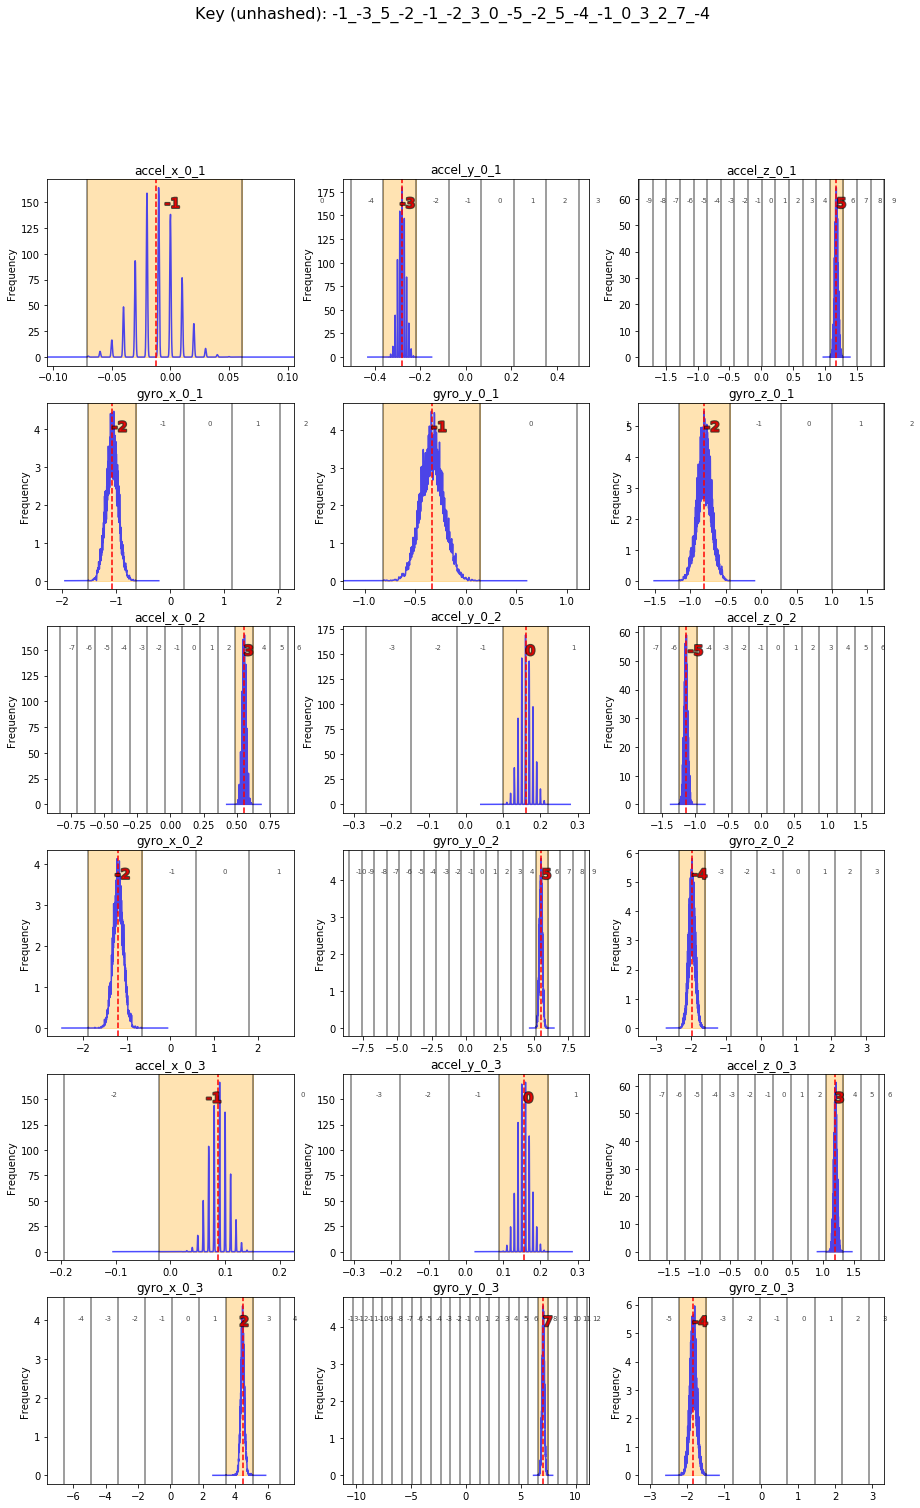

In [4]:
print('Visualising key generation (it takes around 2 minutes on this board)')
visualize_key_generation(features_df, range_sizes, offsets, key, rows_limit=None)

# Continuous key update from sensor data
- compute key continuously from sensor readings
- set the key
- check if trap was detected (send notification through uart to display if yes)

### Make sure to send the encrypted binary through UART to neorv32 bootloader before running cell below.
To compile and encrypt neorv32 binary:
```bash
cd neorv32/sw/examples/demo_cfs
make clean_all image exe ENCRYPTION_KEY=0x...hex_key_obtained_during_training
sudo python3 ../../../tools/upload_through_bootloader.py neorv32_exe.bin
```

TODO: I could implement an input (AXI GPIO) from fpga indicating that the processor is running (e.g. register indicating recent occurence of trace port valid signal being high)

In [7]:
main_stop_queue = queue.Queue()
enable_setting_key = True

def main_operation_worker(range_sizes, offsets, main_stop_queue, enable_setting_key):
    while main_stop_queue.empty():
        hashed_key, key = compute_key_from_mpu_data(range_sizes, offsets, average_over=250, n=1)
        print('key:', hashed_key, f'(unhashed:{key})')
        if enable_setting_key:
            set_neorv32_key(hashed_key)
            send_secondary_key_to_display()
        if trap_detected():
            print('Trap detected, invalid instruction.')            
        while trap_detected() and main_stop_queue.empty():
            uart.write('bad_instr_2000\n')
            time.sleep(3)     
            
            # reset_trap is not really useful because CPU 
            # keeps trapping until it restarts with a correct key.
            
            # Setting key without reset is not enough because
            # the old invalid instruction of a trap handler is
            # not fetched again and causing endless loop.
            reset_trap() 
    while not main_stop_queue.empty():
        main_stop_queue.get()
    print('Stopping main_operation_worker.')

threading.Thread(target=main_operation_worker, daemon=True, args=(range_sizes, offsets, main_stop_queue, enable_setting_key)).start()

key: 9a7bb023e659200716ac8808f46455eb (unhashed:-1_-2_3_-2_-2_-2_0_0_-6_-3_5_-2_0_-1_7_4_3_-2)
Sending 2nd key: d0b84e22aa8a14ba4e6e...
Trap detected, invalid instruction.


In [6]:
main_stop_queue.put(True)

key: fd9fcbb91ddf45b58bbd93960295b013 (unhashed:-1_-3_-1_-8_-7_-1_0_-1_-10_-7_0_-1_-2_-2_0_0_0_-1)
Sending 2nd key: d0b84e22aa8a14ba4e6e...
Stopping main_operation_worker.


In [9]:
last_key = ''
for i in range(100):
    mpu9250_dict = read_mpu9250(average_over=250)
    features_dict = mpu9250_dict_to_features_dict(mpu9250_dict)
#     features_dict = average_dict_values(features_dict)
    key = generate_key_from_features_row(features_dict.values(), range_sizes, offsets)
    if last_key != key:
        print('\n\n\nnew key!')
        last_key = key
    print('key:', key)
    hashed_key = hash_key(key, bit_width=128)
    print('hashed key:', hashed_key)




new key!
key: -8_-14_0_-9_-11_0_-2_-9_-14_-9_0_-3_-7_-9_0_0_3_-3
hashed key: eed9069e89c8029ce99cf09c9aebf5fd



new key!
key: -8_-14_0_-9_-11_0_-2_-9_-14_-9_0_-3_-7_-9_0_0_2_-3
hashed key: 234abd69770ebf89d40e6c86332a00fd



new key!
key: -8_-14_0_-9_-11_0_-2_-9_-14_-9_0_-3_-7_-9_0_0_3_-3
hashed key: eed9069e89c8029ce99cf09c9aebf5fd



new key!
key: -8_-14_0_-9_-11_0_-3_-9_-14_-9_0_-3_-7_-9_-1_0_3_-3
hashed key: 68ed6b1f54d537ec55bfd256f78be0ea



new key!
key: -1_-4_7_-3_-1_-2_4_1_-9_-3_8_-5_0_0_5_6_11_-5
hashed key: fe50a3f8560f816b80be70ea4417a6a9



new key!
key: -1_-4_8_-3_-1_-2_4_1_-8_-3_8_-5_0_0_6_6_11_-5
hashed key: 635d670ba53504467ece40659e6a0c39
key: -1_-4_8_-3_-1_-2_4_1_-8_-3_8_-5_0_0_6_6_11_-5
hashed key: 635d670ba53504467ece40659e6a0c39
key: -1_-4_8_-3_-1_-2_4_1_-8_-3_8_-5_0_0_6_6_11_-5
hashed key: 635d670ba53504467ece40659e6a0c39
key: -1_-4_8_-3_-1_-2_4_1_-8_-3_8_-5_0_0_6_6_11_-5
hashed key: 635d670ba53504467ece40659e6a0c39
key: -1_-4_8_-3_-1_-2_4_1_-8_-3_8_-5_0_0_6_

# Old cells:

In [ ]:
all_dicts = []
for i in range(5):
    start_time = time.time()
    mpu_dict = read_mpu9250()
    all_dicts.append(mpu_dict)
    time_taken = time.time() - start_time
    print(time_taken)

In [2]:
# from pynq.lib.iic import AxiIIC

# # open I²C bus 0 (the upstream Cadence controller at e0004000)
# # address 0x70 = TCA9548A default when A0/A1/A2 = GND
# iic = AxiIIC(base.ip_dict['axi_iic_0'])

In [3]:

# MPU_ADDR   = 0x69          # 0x69 if AD0 pulled high
# WHO_AM_I   = 0x75
# PWR_MGMT_1 = 0x6B

# # --- helpers (thin wrappers around AxiIIC) ---
# def i2c_write_reg(iic, addr, reg, *data_bytes):
#     """Write 1+ bytes starting at 'reg'."""
#     payload = [reg] + list(data_bytes)
#     iic.send(addr, payload, len(payload), option=1)   # STOP at end

# def i2c_read_reg(iic, addr, reg, nbytes):
#     """Read nbytes starting at 'reg' using repeated-start."""
#     # send register pointer (NO stop)
#     iic.send(addr, [reg], 1, option=0)
#     # receive nbytes (WITH stop)
#     rx = [0] * nbytes
#     iic.receive(addr, rx, nbytes, option=1)
#     return rx

# # --- examples ---

# # 0) Wake the chip (clear SLEEP bit)
# i2c_write_reg(iic, MPU_ADDR, PWR_MGMT_1, 0x00)

# # 1) Read WHO_AM_I (expect 0x71 on MPU-9250)
# who = i2c_read_reg(iic, MPU_ADDR, WHO_AM_I, 1)[0]
# print("WHO_AM_I =", hex(who))

# # 2) Write a config register (example: sample rate divider at 0x19)
# i2c_write_reg(iic, MPU_ADDR, 0x19, 0x07)  # SMPLRT_DIV = 7

# # 3) Burst-read 14 bytes of accel/temperature/gyro starting at 0x3B
# raw_imu = i2c_read_reg(iic, MPU_ADDR, 0x3B, 14)
# print("Raw IMU (14 bytes):", raw_imu)

RuntimeError: Could not send I2C data

In [3]:
# MPU9250_ADDR = 0x69
# TCA9548A_ADDR = 0x70

# MPU9250_WAKE_ADDR = 0x6B # single byte to send
# MPU9250_WHO_AM_I_ADDR = 0x75
# MPU9250_DATA_ADDR = 0x3B # 14 bytes

In [26]:
# select channel 0
channel = 0
data = [1 << channel]
iic.send(TCA9548A_ADDR, data, len(data))

1

In [4]:
# select channel 0
channel = 0
data = [MPU9250_WAKE_ADDR, 0]
iic.send(MPU9250_ADDR, data, len(data), option=0)
# data = [0]
# iic.send(MPU9250_ADDR, data, len(data), option=0)
# iic.send(MPU9250_ADDR, data, len(data), 1)

2

In [14]:
data = [MPU9250_WAKE_ADDR]
iic.send(MPU9250_ADDR, data, len(data), option=1)
data = [0]
iic.send(MPU9250_ADDR, data, len(data), option=0)

RuntimeError: Could not send I2C data

In [15]:
data = [MPU9250_WHO_AM_I_ADDR]
iic.send(MPU9250_ADDR, data, len(data), option=1)
read_data = []
iic.receive(MPU9250_ADDR, read_data, 1, option=0)
print(f'read_data={read_data}')

RuntimeError: Could not send I2C data

In [16]:
data = [MPU9250_DATA_ADDR]
iic.send(MPU9250_ADDR, data, len(data), option=1)
read_data = [0] * 14
iic.receive(MPU9250_ADDR, read_data, len(read_data))
print(f'read_data={read_data}')

RuntimeError: Could not send I2C data

In [6]:
read_data = []
iic.receive(MPU9250_ADDR, read_data, 1)

RuntimeError: Could not receive I2C data

In [ ]:

def get_confidence_score(training_features_df, current_features_dict):
    """ Get a score that indicates how likely the exact MPU9250 sensors we just 
    collected a reading from were the same MPU9250 sensors that was used for training. """
    scores_dict = {}
    final_score = 0
    for feature_name, value in current_features_dict.items():
        score = kde_density_score(training_features_df[feature_name].values, [value])[0]
        scores_dict[feature_name] = score
#         final_score *= score
        final_score += score
    final_score /= len(scores_dict)
    return final_score, scores_dict

def get_average_of_confidence_scores(training_features_df, list_of_current_features_dicts):
    scores_dict = {}
    final_score = 0
    for i, current_features_dict in enumerate(list_of_current_features_dicts):
        for feature_name, value in current_features_dict.items():
            score = kde_density_score(training_features_df[feature_name].values, [value])[0]
            if feature_name not in scores_dict:
                scores_dict[feature_name] = score
            else:
                scores_dict[feature_name] += score
    
    for feature_name in scores_dict.keys():
        scores_dict[feature_name] /= len(list_of_current_features_dicts)
        final_score += scores_dict[feature_name]
    final_score /= len(scores_dict)
    return final_score, scores_dict

# Example confidences with the same sensors that were used for training:
# accel_x_0_1 [0.5242099]
# accel_y_0_1 [1.]
# accel_z_0_1 [1.]
# gyro_x_0_1 [0.78489504]
# gyro_y_0_1 [0.808318]
# gyro_z_0_1 [1.]
# temp_0_1 [0.6292479]
# accel_x_0_2 [1.]
# accel_y_0_2 [1.]
# accel_z_0_2 [1.]
# gyro_x_0_2 [0.48917881]
# gyro_y_0_2 [0.89415236]
# gyro_z_0_2 [0.96708131]
# temp_0_2 [0.69730635]
# accel_x_0_3 [1.]
# accel_y_0_3 [1.]
# accel_z_0_3 [0.70422186]
# gyro_x_0_3 [0.88337351]
# gyro_y_0_3 [0.14638723]
# gyro_z_0_3 [0.98437817]
# temp_0_3 [0.46017009]

# Example confidences with the same sensors that were used for training:
# (but after removing and reattaching on of the MPU sensors)
# accel_x_0_1 [6.14905271e-121]
# accel_y_0_1 [1.]
# accel_z_0_1 [1.]
# gyro_x_0_1 [0.62687734]
# gyro_y_0_1 [0.32585386]
# gyro_z_0_1 [1.]
# temp_0_1 [8.92683676e-15]
# accel_x_0_2 [0.]
# accel_y_0_2 [1.]
# accel_z_0_2 [0.85931133]
# gyro_x_0_2 [0.39447215]
# gyro_y_0_2 [0.66188117]
# gyro_z_0_2 [0.07978781]
# temp_0_2 [1.84857124e-23]
# accel_x_0_3 [0.]
# accel_y_0_3 [1.]
# accel_z_0_3 [0.70422186]
# gyro_x_0_3 [0.11690979]
# gyro_y_0_3 [0.71055705]
# gyro_z_0_3 [0.20310882]
# temp_0_3 [9.09656055e-137]

# NOTE: values above show that multiplication of all scores is not a good idea, because
#       some individual scores are 0 despite coming from the same set of sensors (but reattached)

# Condidences after replacing one of the sensors that were used for training:
# accel_x_0_1 [0.03228044]
# accel_y_0_1 [0.]
# accel_z_0_1 [7.5974266e-102]
# gyro_x_0_1 [0.85395382]
# gyro_y_0_1 [0.]
# gyro_z_0_1 [2.81154605e-07]
# temp_0_1 [0.06159768]
# accel_x_0_2 [0.00421921]
# accel_y_0_2 [0.]
# accel_z_0_2 [4.25124741e-73]
# gyro_x_0_2 [0.66706589]
# gyro_y_0_2 [2.327061e-174]
# gyro_z_0_2 [4.80674706e-07]
# temp_0_2 [4.19679345e-05]
# accel_x_0_3 [0.00084384]
# accel_y_0_3 [0.]
# accel_z_0_3 [3.3088223e-46]
# gyro_x_0_3 [0.25027737]
# gyro_y_0_3 [0.]
# gyro_z_0_3 [1.36480894e-14]
# temp_0_3 [1.81137418e-25]

all_final_scores = []
for i in range(70):
    mpu9250_dict = read_mpu9250()
    features_dict = mpu9250_dict_to_features_dict(mpu9250_dict)
    final_score, scores_dict = get_confidence_score(features_df, features_dict)
    print(final_score)
#     for feature_name, score in scores_dict.items():
#         print(feature_name, score)
    print()
    all_final_scores.append(final_score)
pd.DataFrame(all_final_scores).hist()

In [ ]:

all_final_scores = []
for i in range(70):
    mpu9250_dicts = read_mpu9250_n_times(3)
    features_dicts = many_mpu9250_dicts_to_features_dicts(mpu9250_dicts)
    final_score, scores_dict = get_average_of_confidence_scores(features_df, features_dicts)
    print(final_score)
#     for feature_name, score in scores_dict.items():
#         print(feature_name, score)
    print()
    all_final_scores.append(final_score)
pd.DataFrame(all_final_scores).hist()

In [ ]:
all_final_scores = []
for i in range(70):
    mpu9250_dict = read_mpu9250()
    features_dict = mpu9250_dict_to_features_dict(mpu9250_dict)
    final_score, scores_dict = get_confidence_score(features_df, features_dict)
    print(final_score)
#     for feature_name, score in scores_dict.items():
#         print(feature_name, score)
    print()
    all_final_scores.append(final_score)
pd.DataFrame(all_final_scores).hist()